<a href="https://colab.research.google.com/github/Sirigalla34/deep-learning-programs/blob/main/rnn_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.5869 - loss: 0.6544 - val_accuracy: 0.8166 - val_loss: 0.4077
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.8476 - loss: 0.3568 - val_accuracy: 0.6498 - val_loss: 0.6205
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.8283 - loss: 0.3930 - val_accuracy: 0.8308 - val_loss: 0.4260
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.9519 - loss: 0.1419 - val_accuracy: 0.8156 - val_loss: 0.4816
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.9846 - loss: 0.0597 - val_accuracy: 0.8314 - val_loss: 0.5360
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8240 - loss: 0.5460
Test Accuracy: 0.8247600197792053


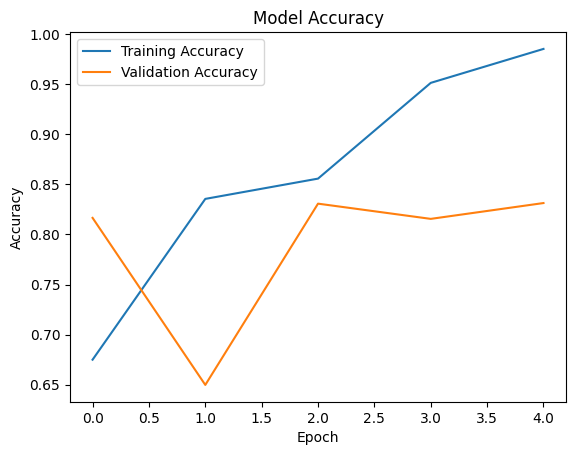

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt
# Load IMDB dataset (top 10,000 most frequent words)
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)
# Pad sequences so all reviews have the same length
max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)
# Build the RNN model
model = Sequential()
# Embedding layer converts word indexes into dense vectors
model.add(Embedding(input_dim=vocab_size, output_dim=32))
# Simple RNN layer for sequential text processing
model.add(SimpleRNN(32))
# Output layer for binary classification (positive / negative)
model.add(Dense(1, activation='sigmoid'))
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)
# Evaluate model on test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)
# Plot training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()